In [1]:
#importing base modules
import numpy as np
import pandas as pd


#visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#depecrated package warnings
import warnings
warnings.filterwarnings("ignore")


**Data Loading**

In [2]:
#Loading data as pandas DF

raw = pd.read_csv(r"C:\work\Data.csv")

In [3]:
df = pd.read_csv(r"C:\work\Data.csv")

In [4]:
df.shape

(907, 12)

In [5]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    object 
 1   City               907 non-null    object 
 2   University         907 non-null    object 
 3   Program            907 non-null    object 
 4   Level              907 non-null    object 
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 85.2+ KB


**1.Data Validation**

In [7]:
#converting the data into lower case
for col in df.select_dtypes("O").columns:
    df[col] = df[col].str.lower()

In [8]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,usa,cambridge,harvard university,computer science,master,2.0,55400,83.5,2200,160,1500,1.00
1,uk,london,imperial college london,data science,master,1.0,41200,75.8,1800,485,800,0.79
2,canada,toronto,university of toronto,business analytics,master,2.0,38500,72.5,1600,235,900,1.35
3,australia,melbourne,university of melbourne,engineering,master,2.0,42000,71.2,1400,450,650,1.52
4,germany,munich,technical university of munich,mechanical engineering,master,2.0,500,70.5,1100,75,550,0.92


In [9]:
df.columns = df.columns.str.lower()

In [10]:
df.head()

,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate
0,usa,cambridge,harvard university,computer science,master,2.0,55400,83.5,2200,160,1500,1.00
1,uk,london,imperial college london,data science,master,1.0,41200,75.8,1800,485,800,0.79
2,canada,toronto,university of toronto,business analytics,master,2.0,38500,72.5,1600,235,900,1.35
3,australia,melbourne,university of melbourne,engineering,master,2.0,42000,71.2,1400,450,650,1.52
4,germany,munich,technical university of munich,mechanical engineering,master,2.0,500,70.5,1100,75,550,0.92


In [11]:
#validating each data column with its data type
df.country

0               usa
1                uk
2            canada
3         australia
4           germany
           ...     
902          france
903        malaysia
904    saudi arabia
905             usa
906              uk
Name: country, Length: 907, dtype: object

In [12]:
df.country.nunique()

71

In [13]:
df.country.unique()

array(['usa', 'uk', 'canada', 'australia', 'germany', 'japan',
       'netherlands', 'singapore', 'france', 'switzerland', 'sweden',
       'denmark', 'china', 'south korea', 'ireland', 'new zealand',
       'austria', 'belgium', 'hong kong', 'portugal', 'israel', 'taiwan',
       'czech republic', 'india', 'poland', 'malaysia', 'spain', 'italy',
       'finland', 'norway', 'brazil', 'turkey', 'russia', 'mexico',
       'greece', 'thailand', 'uae', 'south africa', 'egypt', 'argentina',
       'indonesia', 'saudi arabia', 'nigeria', 'vietnam', 'hungary',
       'iceland', 'colombia', 'romania', 'luxembourg', 'tunisia',
       'cyprus', 'croatia', 'dominican republic', 'morocco', 'peru',
       'ecuador', 'lebanon', 'bahrain', 'uruguay', 'bulgaria', 'ghana',
       'algeria', 'panama', 'bangladesh', 'kuwait', 'ukraine', 'slovenia',
       'serbia', 'iran', 'uzbekistan', 'el salvador'], dtype=object)

In [14]:
df.city

0       cambridge
1          london
2         toronto
3       melbourne
4          munich
          ...    
902    strasbourg
903         nilai
904       al-ahsa
905       seattle
906    nottingham
Name: city, Length: 907, dtype: object

In [15]:
df.city.unique()

array(['cambridge', 'london', 'toronto', 'melbourne', 'munich', 'tokyo',
       'amsterdam', 'singapore', 'paris', 'zurich', 'stockholm',
       'copenhagen', 'beijing', 'seoul', 'dublin', 'busan', 'auckland',
       'vienna', 'brussels', 'ann arbor', 'atlanta', 'austin', 'bristol',
       'ottawa', 'hong kong', 'lisbon', 'tel aviv', 'taipei', 'prague',
       'stanford', 'boston', 'oxford', 'heidelberg', 'basel', 'delft',
       'waterloo', 'canberra', 'lund', 'san diego', 'seattle', 'edmonton',
       'glasgow', 'bangalore', 'aalborg', 'warsaw', 'galway', 'daejeon',
       'kuala lumpur', 'berkeley', 'manchester', 'vancouver', 'sydney',
       'berlin', 'barcelona', 'milan', 'rotterdam', 'helsinki', 'oslo',
       'osaka', 'kyoto', 'nagoya', 'sendai', 'fukuoka', 'sapporo',
       'tsukuba', 'kobe', 'kanazawa', 'hiroshima', 'adelaide', 'perth',
       'gold coast', 'hobart', 'newcastle', 'wollongong', 'darwin',
       'townsville', 'sunshine coast', 'armidale', 'dresden', 'stuttgart',

In [16]:
df.university

0                  harvard university
1             imperial college london
2               university of toronto
3             university of melbourne
4      technical university of munich
                    ...              
902          university of strasbourg
903                              usim
904            king faisal university
905          university of washington
906          university of nottingham
Name: university, Length: 907, dtype: object

In [17]:
df.university.unique()

array(['harvard university', 'imperial college london',
       'university of toronto', 'university of melbourne',
       'technical university of munich', 'university of tokyo',
       'university of amsterdam', 'national university of singapore',
       'sorbonne university', 'eth zurich', 'kth royal institute',
       'university of copenhagen', 'tsinghua university',
       'seoul national university', 'trinity college dublin',
       'pusan national university', 'university of auckland',
       'university of vienna', 'ku leuven', 'university of michigan',
       'georgia tech', 'ut austin', 'university of bristol',
       'university of ottawa', 'hkust', 'university of lisbon',
       'tel aviv university', 'national taiwan university',
       'charles university', 'stanford university', 'mit',
       'university of oxford', 'university of cambridge',
       'heidelberg university', 'eth basel', 'tu delft', 'ntu singapore',
       'university of waterloo', 'australian national un

In [18]:
df.program

0            computer science
1                data science
2          business analytics
3                 engineering
4      mechanical engineering
                ...          
902            data analytics
903          computer science
904       information systems
905      software development
906          data engineering
Name: program, Length: 907, dtype: object

In [19]:
df.program.unique()

array(['computer science', 'data science', 'business analytics',
       'engineering', 'mechanical engineering', 'information science',
       'artificial intelligence', 'finance', 'international relations',
       'physics', 'sustainable technology', 'bioinformatics',
       'computer engineering', 'digital media', 'data analytics',
       'business', 'marine biology', 'social sciences',
       'biomedical sciences', 'aerospace engineering',
       'industrial engineering', 'chemical engineering', 'mathematics',
       'political science', 'architecture', 'electronics engineering',
       'medicine', 'electrical engineering', 'molecular biology',
       'pharmaceutical sciences', 'robotics', 'quantum computing',
       'climate science', 'neuroscience', 'economics', 'psychology',
       'international business', 'design', 'environmental science',
       'software engineering', 'information systems',
       'information technology', 'software development',
       'computing science', '

In [20]:
df.level

0        master
1        master
2        master
3        master
4        master
         ...   
902      master
903    bachelor
904      master
905         phd
906      master
Name: level, Length: 907, dtype: object

In [21]:
df.level.nunique()

3

In [22]:
df.level.unique()

array(['master', 'bachelor', 'phd'], dtype=object)

In [23]:
#handling duplicates
df[df.duplicated()]

,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate


In [24]:
int(df.duplicated().sum())

0

In [25]:
#here we don't have any duplicate rows if it occurs we should handle by writing the command
#  "df = df.drop_duplicates().reset_index(drop=True)"

In [26]:
df.shape

(907, 12)

**2.EDA-Exploratory Data Analysis**

Data will be studies in uni and bi\multi variate with the help pod descriptive statistics or visuals

**Fundamentals of stats**

what data we got ? -sample\population whats in the data? -variables and types

**Uni-variate(study of cols data individually)**

In [27]:
df["duration_years"]

0      2.0
1      1.0
2      2.0
3      2.0
4      2.0
      ... 
902    2.0
903    3.0
904    2.0
905    5.0
906    2.0
Name: duration_years, Length: 907, dtype: float64

In [28]:
round(df.duration_years.describe(),2)

count    907.00
mean       2.84
std        0.95
min        1.00
25%        2.00
50%        3.00
75%        4.00
max        5.00
Name: duration_years, dtype: float64

In [29]:
df["tuition_usd"]

0      55400
1      41200
2      38500
3      42000
4        500
       ...  
902     4000
903     6800
904     4200
905    50000
906    34000
Name: tuition_usd, Length: 907, dtype: int64

In [30]:
round(df.tuition_usd.describe(),2)

count      907.00
mean     16705.02
std      16582.39
min          0.00
25%       2850.00
50%       7500.00
75%      31100.00
max      62000.00
Name: tuition_usd, dtype: float64

In [31]:
df["living_cost_index"]

0      83.5
1      75.8
2      72.5
3      71.2
4      70.5
       ... 
902    70.2
903    50.5
904    64.2
905    77.8
906    61.2
Name: living_cost_index, Length: 907, dtype: float64

In [32]:
round(df.living_cost_index.describe(),2)

count    907.00
mean      64.44
std       14.06
min       27.80
25%       56.30
50%       67.50
75%       72.20
max      122.40
Name: living_cost_index, dtype: float64

In [33]:
df["rent_usd"]

0      2200
1      1800
2      1600
3      1400
4      1100
       ... 
902    1000
903     400
904     600
905    2000
906     800
Name: rent_usd, Length: 907, dtype: int64

In [34]:
round(df.rent_usd.describe(),2)

count     907.00
mean      969.21
std       517.15
min       150.00
25%       545.00
50%       900.00
75%      1300.00
max      2500.00
Name: rent_usd, dtype: float64

In [35]:
df["visa_fee_usd"]

0      160
1      485
2      235
3      450
4       75
      ... 
902     99
903    120
904    200
905    160
906    485
Name: visa_fee_usd, Length: 907, dtype: int64

In [36]:
round(df.visa_fee_usd.describe(),2)

count    907.00
mean     211.40
std      143.44
min       40.00
25%      100.00
50%      160.00
75%      240.00
max      490.00
Name: visa_fee_usd, dtype: float64

In [37]:
df["insurance_usd"]

0      1500
1       800
2       900
3       650
4       550
       ... 
902     850
903     400
904     800
905    1500
906     800
Name: insurance_usd, Length: 907, dtype: int64

In [38]:
round(df.insurance_usd.describe(),2)

count     907.00
mean      700.08
std       320.37
min       200.00
25%       450.00
50%       650.00
75%       800.00
max      1500.00
Name: insurance_usd, dtype: float64

In [39]:
df["country"]

0               usa
1                uk
2            canada
3         australia
4           germany
           ...     
902          france
903        malaysia
904    saudi arabia
905             usa
906              uk
Name: country, Length: 907, dtype: object

In [40]:
df["country"].mode()

0    uk
Name: country, dtype: object

In [41]:
df[df["country"]=="usa"]

,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate
0,usa,cambridge,harvard university,computer science,master,2.0,55400,83.5,2200,160,1500,1.0
19,usa,ann arbor,university of michigan,aerospace engineering,bachelor,4.0,52300,72.5,1800,160,1500,1.0
20,usa,atlanta,georgia tech,industrial engineering,bachelor,4.0,43800,71.5,1700,160,1500,1.0
21,usa,austin,ut austin,chemical engineering,bachelor,4.0,40900,72.4,1600,160,1500,1.0
29,usa,stanford,stanford university,computer science,phd,5.0,54200,89.5,2300,160,1500,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
877,usa,new york,columbia university,data science,master,2.0,62000,100.0,2500,160,1500,1.0
884,usa,los angeles,ucla,computer engineering,phd,5.0,52000,79.8,2200,160,1500,1.0
891,usa,chicago,university of chicago,artificial intelligence,master,2.0,58000,84.1,1900,160,1500,1.0
898,usa,san francisco,stanford university,data science,master,2.0,55000,95.2,2400,160,1500,1.0


In [42]:
df["city"].mode()

0    singapore
Name: city, dtype: object

In [43]:
df["university"].mode()

0    university of washington
Name: university, dtype: object

In [44]:
df["program"].mode()

0    computer science
Name: program, dtype: object

In [45]:
df["level"].mode()

0    master
Name: level, dtype: object

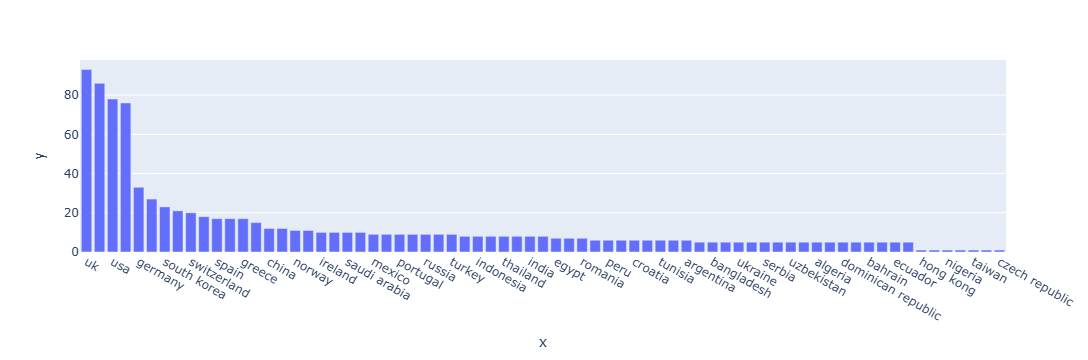

In [46]:
#visuals
cats = df.country.value_counts()[0:1000].index
vals = df.country.value_counts()[0:1000].values
px.bar(x=cats,y=vals)

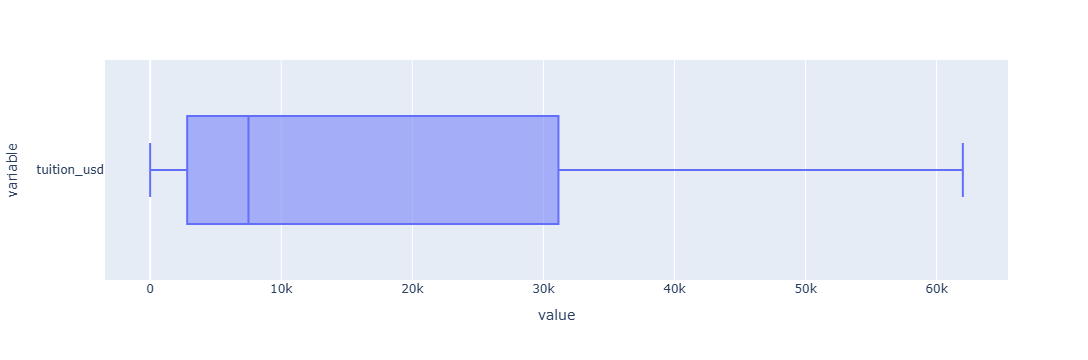

In [47]:
px.box(df.tuition_usd,orientation="h")

**insights**

**Bi/Multi variate Analysis**

In [48]:
df.head()

,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate
0,usa,cambridge,harvard university,computer science,master,2.0,55400,83.5,2200,160,1500,1.00
1,uk,london,imperial college london,data science,master,1.0,41200,75.8,1800,485,800,0.79
2,canada,toronto,university of toronto,business analytics,master,2.0,38500,72.5,1600,235,900,1.35
3,australia,melbourne,university of melbourne,engineering,master,2.0,42000,71.2,1400,450,650,1.52
4,germany,munich,technical university of munich,mechanical engineering,master,2.0,500,70.5,1100,75,550,0.92


In [49]:
round(df.groupby("country")["tuition_usd"].mean(),2).sort_values(ascending=False)

country
usa          47742.31
australia    34610.47
singapore    34172.22
uk           30341.94
canada       29456.58
               ...   
norway           0.00
finland          0.00
iceland          0.00
argentina        0.00
sweden           0.00
Name: tuition_usd, Length: 71, dtype: float64

In [50]:
#to check the mean of the tuition_usd in usa use this code
df[df["country"]=="usa"]
usa_rows = df[df["country"]=="usa"]
round(usa_rows["tuition_usd"].mean(),2)

np.float64(47742.31)

In [51]:
df[df["tuition_usd"]==0]["country"].unique()

array(['sweden', 'denmark', 'germany', 'finland', 'norway', 'brazil',
       'argentina', 'greece', 'iceland', 'uruguay'], dtype=object)

In [52]:
round(df.groupby("university")["tuition_usd"].mean(),2).sort_values(ascending=False)

university
columbia university              58933.33
harvard university               56700.00
university of chicago            56133.33
massachusetts                    56000.00
mit                              55866.67
                                   ...   
university of turku                  0.00
university of piraeus                0.00
kth royal institute                  0.00
roskilde university                  0.00
university of eastern finland        0.00
Name: tuition_usd, Length: 622, dtype: float64

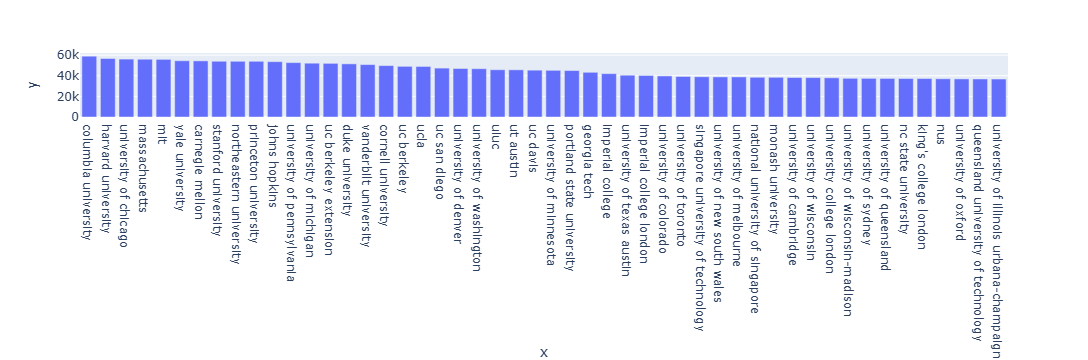

In [53]:
#visuals
cats = round(df.groupby("university")["tuition_usd"].mean(),2).sort_values(ascending=False)[0:50].index
vals = round(df.groupby("university")["tuition_usd"].mean(),2).sort_values(ascending=False)[0:50].values
px.bar(x=cats,y=vals)

In [54]:
df[df["university"]=="columbia university"]

,country,city,university,program,level,duration_years,tuition_usd,living_cost_index,rent_usd,visa_fee_usd,insurance_usd,exchange_rate
131,usa,new york,columbia university,data science,master,2.0,52800,100.0,2500,160,1500,1.0
412,usa,new york,columbia university,economics,master,2.0,62000,100.0,2500,160,1500,1.0
877,usa,new york,columbia university,data science,master,2.0,62000,100.0,2500,160,1500,1.0


**country vs university vs tuition_usd(multi-mixed)**

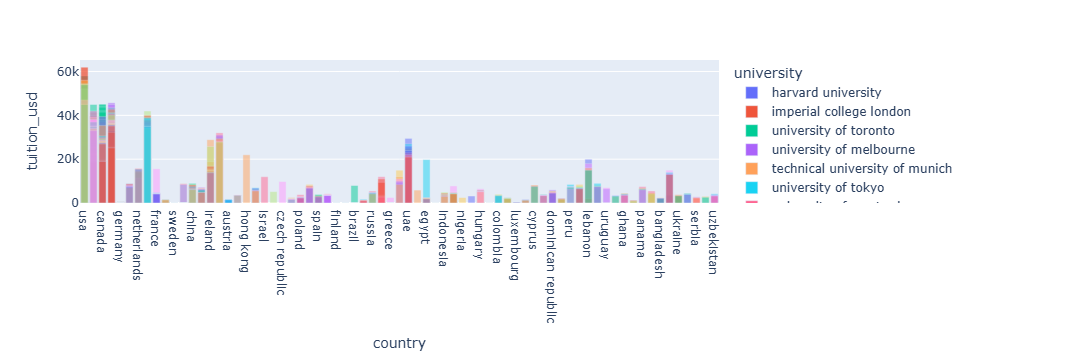

In [55]:
px.bar(df,x="country",y="tuition_usd",color="university",barmode="overlay")

In [56]:
round(df.groupby(["country","university"])["tuition_usd"].mean(),2).sort_values(ascending=False)

country  university             
usa      columbia university        58933.33
         harvard university         56700.00
         university of chicago      56133.33
         massachusetts              56000.00
         mit                        55866.67
                                      ...   
finland  university of helsinki         0.00
         university of jyväskylä        0.00
         university of oulu             0.00
         university of turku            0.00
sweden   lund university                0.00
Name: tuition_usd, Length: 623, dtype: float64

In [57]:
round(df[df["country"]=="india"]["tuition_usd"].mean(),2)

np.float64(1900.0)

In [58]:
df[["living_cost_index","rent_usd"]]

,living_cost_index,rent_usd
0,83.5,2200
1,75.8,1800
2,72.5,1600
3,71.2,1400
4,70.5,1100
...,...,...
902,70.2,1000
903,50.5,400
904,64.2,600
905,77.8,2000


In [59]:
#descriptive stats
round(df[["living_cost_index","rent_usd"]].corr(),2)

,living_cost_index,rent_usd
living_cost_index,1.00,0.81
rent_usd,0.81,1.00


**insights**

**when the living cost index increases then the rent also increasing

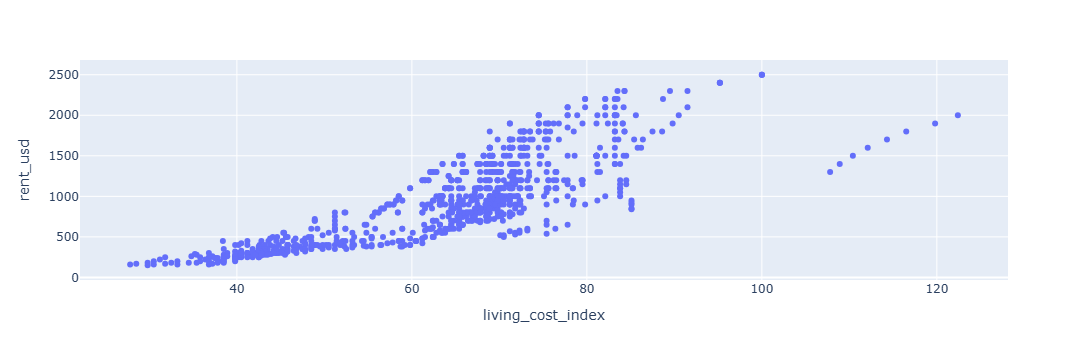

In [60]:
px.scatter(df,x="living_cost_index",y="rent_usd")

In [61]:
#multi variate numerical-we can use heatmaps
round(df[["tuition_usd","living_cost_index","rent_usd"]].corr(),2)

,tuition_usd,living_cost_index,rent_usd
tuition_usd,1.00,0.40,0.72
living_cost_index,0.40,1.00,0.81
rent_usd,0.72,0.81,1.00


<Axes: >

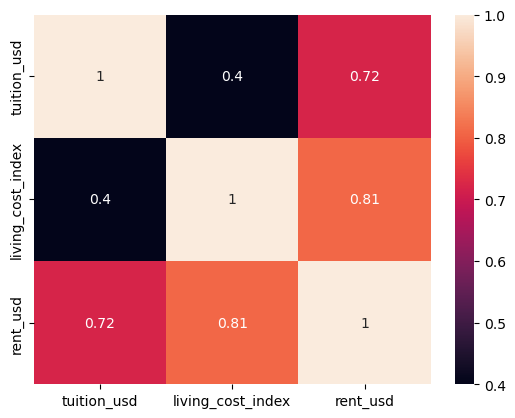

In [62]:
sns.heatmap(round(df[["tuition_usd","living_cost_index","rent_usd"]].corr(),2),annot=True)

**pure categortical**

**country vs level**

In [63]:
#FDT
##descriptive statistics
cross_tab = pd.crosstab(df.country,df.level)
cross_tab['Total'] = cross_tab.sum(axis=1)
cross_tab_sorted = cross_tab.sort_values('Total',ascending=False)

cross_tab_sorted.tail(15)

level,bachelor,master,phd,Total
country,,,,
bangladesh,0,3,2,5
bulgaria,1,3,1,5
dominican republic,2,2,1,5
ecuador,1,2,2,5
el salvador,3,2,0,5
ghana,0,3,2,5
iran,1,2,2,5
lebanon,1,3,1,5
hong kong,1,0,0,1


In [64]:
#visuals
x=pd.crosstab(df.country,df.level).index
y=pd.crosstab(df.country,df.level).values
color=pd.crosstab(df.country,df.level).columns

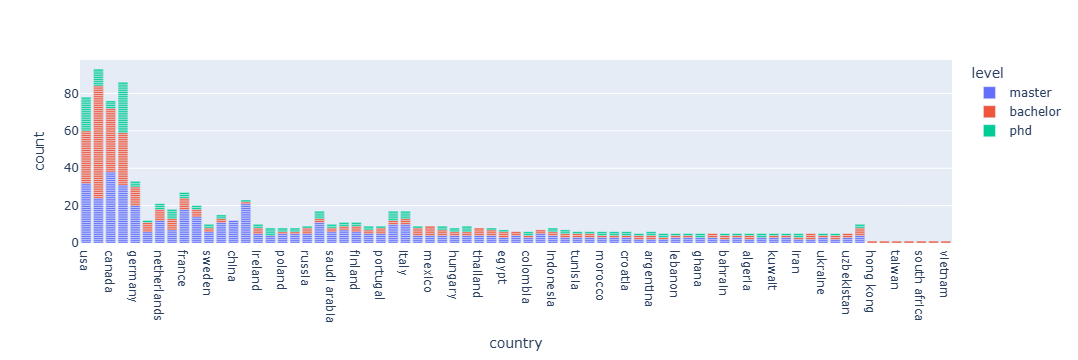

In [65]:
px.bar(df,x='country',color='level')

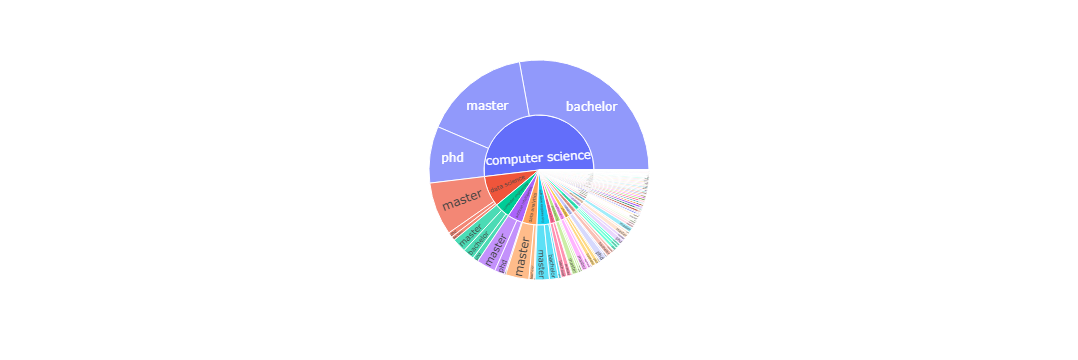

In [66]:
#sunburst chart
px.sunburst(df,path=['program','level'],values='tuition_usd')

**insights**

**overall insights**